In [19]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import talib

In [20]:
path = 'data/0050.TW.csv'
df = pd.read_csv(path)

adj_close = df['Adj Close']
date = df['Date']

In [73]:
def plot_interval(
  beg: str, end: str,
  rsi_short_period: int, rsi_long_period: int
):
  beg_idx = date[date == beg].index
  end_idx = date[date == end].index

  if len(beg_idx) == 0 or len(end_idx) == 0:
    print('Begin date or end date is not available')
    return

  close_price = adj_close[beg_idx[0]:end_idx[0] + 1]
  day_num = close_price.shape[0]
  rsi_fast = talib.RSI(close_price, timeperiod=rsi_short_period)
  rsi_slow = talib.RSI(close_price, timeperiod=rsi_long_period)

  plt.plot(close_price, 'lightgray')
  plt.twinx()
  plt.plot(rsi_fast, 'tab:orange')
  plt.plot(rsi_slow, 'tab:blue')
  plt.title(f'{beg} ~ {end}\n{day_num} trade days', fontsize=10)

In [25]:
def get_nearest_workday(date_str: str) -> str:
  date = datetime.strptime(date_str, '%Y-%m-%d')
  weekday = date.weekday()

  if weekday == 5:
    date -= timedelta(days=1)
  elif weekday == 6:
    date += timedelta(days=1)

  return date.strftime('%Y-%m-%d')

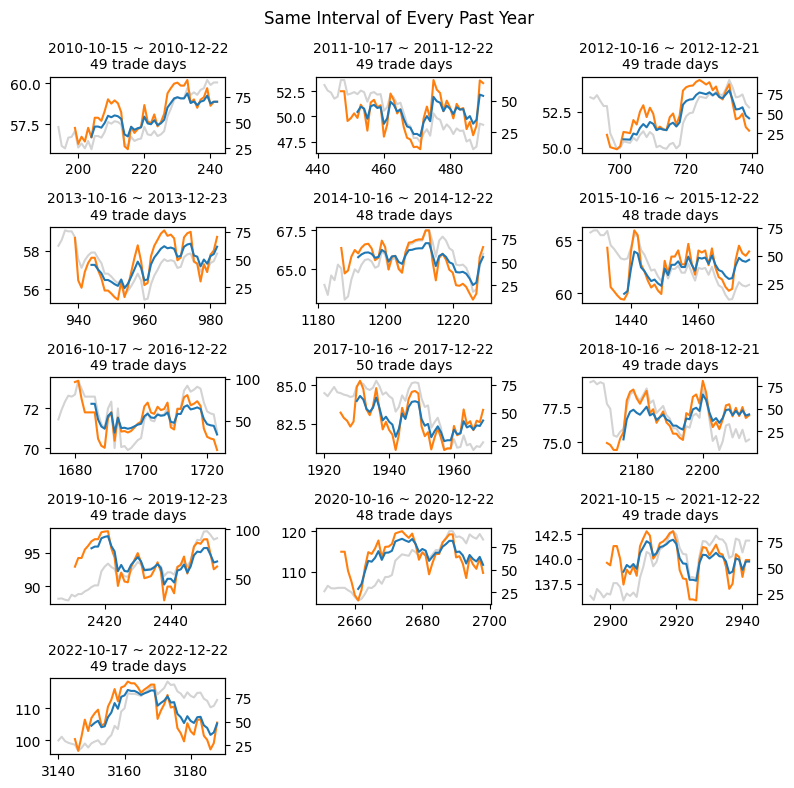

In [74]:
fig = plt.figure(figsize=(8, 8))

for y in range(2010, 2023):
  beg = get_nearest_workday(f'{y}-10-16')
  end = get_nearest_workday(f'{y}-12-22')

  plt.subplot(5, 3, y - 2009)
  plot_interval(beg, end, 5, 10)

plt.suptitle('Same Interval of Every Past Year')
plt.tight_layout()
plt.show()

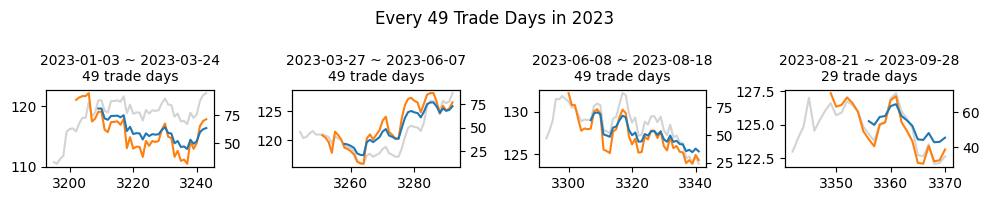

In [82]:
fig = plt.figure(figsize=(10, 2))

n = 49
interval = date[date.str.startswith('2023-')]
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]
for i, split in enumerate(splits):
  beg = split.iloc[0]
  end = split.iloc[-1]

  plt.subplot(1, 4, i + 1)
  plot_interval(beg, end, 7, 14)

plt.suptitle(f'Every {n} Trade Days in 2023')
plt.tight_layout()
plt.show()